# 1. 모델 불러오기

In [1]:
# 라이브러리 설치: uv add ultralytics 
from ultralytics import YOLO

model = YOLO("models/yolo26n.pt") # 다운로드 위치
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

# 2. 이미지 예측하기

In [2]:
results = model(
    source="./images/yolo_image.jpg",
    save=True
)
results


image 1/1 c:\potenup3\pj03_deep_learning\images\yolo_image.jpg: 448x640 7 persons, 3 bicycles, 1 umbrella, 143.0ms
Speed: 5.4ms preprocess, 143.0ms inference, 19.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\potenup3\pj03_deep_learning\runs\detect\predict3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [3]:
# results의 길이 
print(len(results))
print(type(results))

1
<class 'list'>


In [4]:
result = results[0]


In [5]:
print(result.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [6]:
print(result.boxes.cls)

tensor([ 1.,  1.,  1.,  0.,  0., 25.,  0.,  0.,  0.,  0.,  0.], device='cuda:0')


In [7]:
print(result.boxes.data[0])

tensor([6.2340e+02, 4.0262e+02, 1.0344e+03, 7.7300e+02, 9.0550e-01, 1.0000e+00], device='cuda:0')


In [8]:
# index 3번째 객체의 cls, conf, data 출력하기 + cls 가 뭘 의미하는지 names에서 찾기
names = result.names
print("3번째 객체 정보")
print(f"cls: {result.boxes.cls[3]} name: {names[int(result.boxes.cls[3])]}")
print(f"conf: {result.boxes.conf[3]}")
print(f"data: {result.boxes.data[3]}")

3번째 객체 정보
cls: 0.0 name: person
conf: 0.7675918936729431
data: tensor([386.5305, 244.8416, 585.7274, 724.1638,   0.7676,   0.0000], device='cuda:0')


In [9]:
names = result.names
x1, y1,x2,y2,conf,predict = result.boxes.data[0]
print(f"왼쪽 위 좌표:({x1},{y1})")
print(f"오른쪽 아래 좌표:({x2},{y2})")
print(f"Confidence: {conf}")
print(f"객체 분류 결과: {predict}|{names[int(predict)]}")

왼쪽 위 좌표:(623.4019775390625,402.62384033203125)
오른쪽 아래 좌표:(1034.44677734375,773.004150390625)
Confidence: 0.9054966568946838
객체 분류 결과: 1.0|bicycle


In [10]:
# 반복문을 통해서 발견된 객체의 분류 결과를 print하는 코드를 작성해주세요.
# object 변수 설정. 반복문 돌려서 object일 때만 출력하기
object_name = "person"

names = result.names
data = result.boxes.data

for box in data:
    x1, y1,x2,y2,conf,predict = box
    label = names[int(predict)]
    if label == object_name:
        print(f"{object_name}가 감지되었습니다!!!")
        print(f"왼쪽 위 좌표:({x1},{y1})")
        print(f"오른쪽 아래 좌표:({x2},{y2})")
        print(f"Confidence: {conf}")
        print(f"객체 분류 결과: {predict}|{names[int(predict)]}")
        print("="*100)

person가 감지되었습니다!!!
왼쪽 위 좌표:(386.5305480957031,244.841552734375)
오른쪽 아래 좌표:(585.7273559570312,724.163818359375)
Confidence: 0.7675918936729431
객체 분류 결과: 0.0|person
person가 감지되었습니다!!!
왼쪽 위 좌표:(831.0001220703125,179.2593231201172)
오른쪽 아래 좌표:(1018.3544921875,742.143310546875)
Confidence: 0.5614206194877625
객체 분류 결과: 0.0|person
person가 감지되었습니다!!!
왼쪽 위 좌표:(343.7234802246094,258.3402099609375)
오른쪽 아래 좌표:(421.1965637207031,490.7994079589844)
Confidence: 0.42473921179771423
객체 분류 결과: 0.0|person
person가 감지되었습니다!!!
왼쪽 위 좌표:(120.10535430908203,248.0869140625)
오른쪽 아래 좌표:(279.69720458984375,546.079833984375)
Confidence: 0.4010641872882843
객체 분류 결과: 0.0|person
person가 감지되었습니다!!!
왼쪽 위 좌표:(118.20912170410156,243.84481811523438)
오른쪽 아래 좌표:(280.15264892578125,631.6968994140625)
Confidence: 0.28420665860176086
객체 분류 결과: 0.0|person
person가 감지되었습니다!!!
왼쪽 위 좌표:(589.805419921875,217.20767211914062)
오른쪽 아래 좌표:(799.8754272460938,684.9683227539062)
Confidence: 0.26514706015586853
객체 분류 결과: 0.0|person
person가 감지되

person가 감지되었습니다!!!!
person가 감지되었습니다!!!!
person가 감지되었습니다!!!!
person가 감지되었습니다!!!!
person가 감지되었습니다!!!!
person가 감지되었습니다!!!!
person가 감지되었습니다!!!!


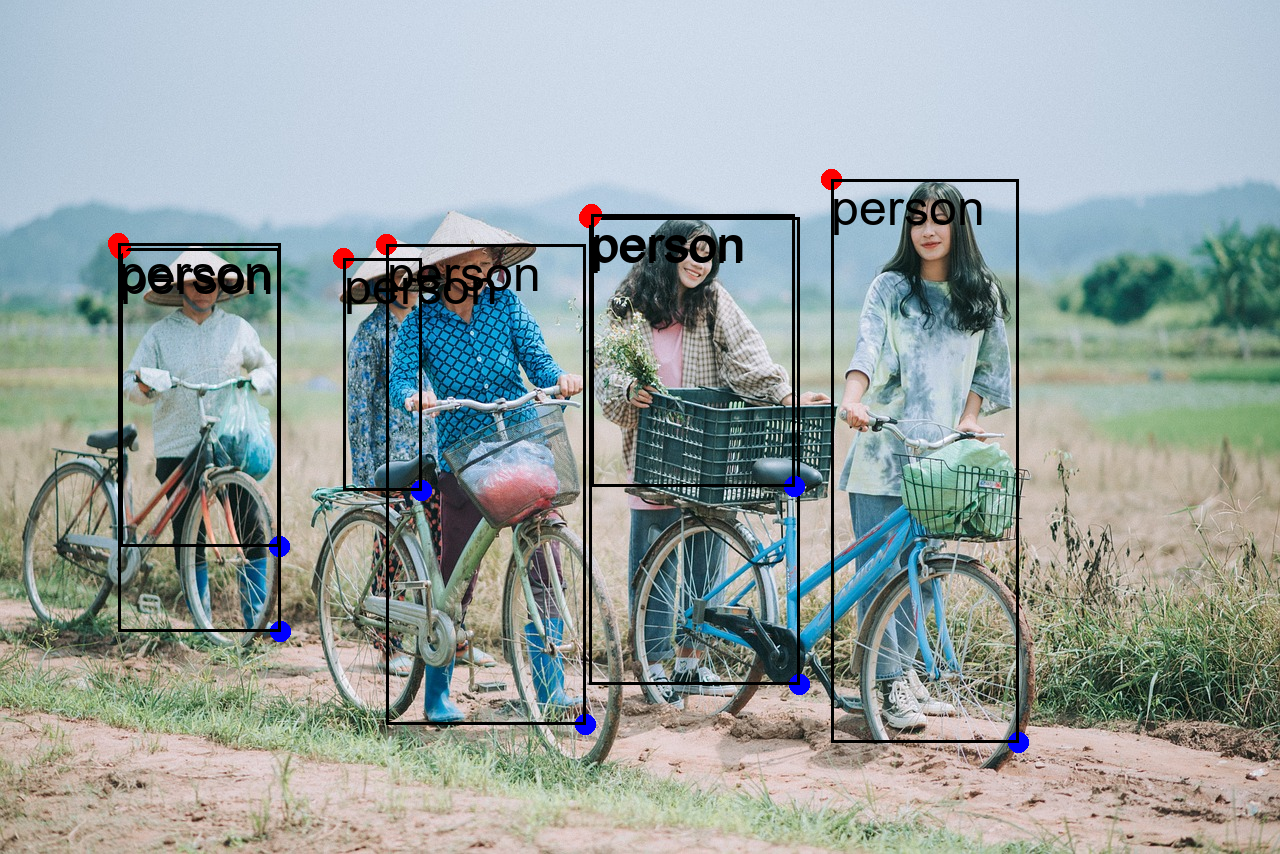

In [12]:
# 객체 그리기
from PIL import Image, ImageDraw
from PIL import ImageFont

object_name = "person"

names = result.names
data = result.boxes.data

img = Image.open("./images/yolo_image.jpg")
draw = ImageDraw.Draw(img)
font = ImageFont.truetype("C:/Windows/Fonts/ARIAL.TTF", size=50)
r = 10 # 반지름

for box in data:
    x1, y1, x2, y2, conf, predict = box
    label = names[int(predict)]
    if label == object_name:
        print(f"{object_name}가 감지되었습니다!!!!")
        # 왼쪽 위 좌표 점으로 표시하기
        draw.ellipse([x1-r, y1-r, x1+r, y1+r], fill="red")
        # 오른쪽 좌표 점으로 표시하기
        draw.ellipse([x2-r, y2-r, x2+r, y2+r], fill="blue")
        # 박스 그리기
        draw.rectangle([x1, y1, x2, y2], outline="black", width=3)
        # 라벨 출력
        draw.text((x1, y1), text=names[int(predict)], fill="black", font=font)

img

# 3. 모델 학습하기

In [ ]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="asd")
project = rf.workspace("s-workspace-5b5vr").project("dogcatproject-p6wfp")
version = project.version(1)
dataset = version.download("yolo26")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DogCatProject-1 in yolo26:: 100%|██████████| 92/92 [00:00<00:00, 3807.25it/s]


## 2) 모델 불러오기

In [1]:
from ultralytics import YOLO

model = YOLO("models/yolo26n.pt") # 다운로드 위치

## 3) 학습하기

In [ ]:
results = model.train(
    data="./DogCatProject-1/data.yaml",    #data.yaml 파일 경로
    epochs=100, # 학습 개수
    imgsz=640,  # 이미지 리사이즈 크기
    project="yolo_run",  # 저장할 폴더
    # device = 0
)

New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.14.3 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./roboflow/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

# 4. 내 모델 불러오기

In [2]:
from ultralytics import YOLO

mymodel = YOLO(r"C:\potenup3\pj03_deep_learning\runs\detect\yolo_run\train\weights\best.pt")

# 5. 예측 테스트

In [3]:
results = mymodel.predict(
    source=r"C:\potenup3\pj03_deep_learning\images\dogandcat.jpeg",
    save=True
)


image 1/1 C:\potenup3\pj03_deep_learning\images\dogandcat.jpeg: 448x640 1 cat, 65.1ms
Speed: 15.1ms preprocess, 65.1ms inference, 20.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\potenup3\pj03_deep_learning\runs\detect\predict5
